## HB level 2 assignment probability and Danger Zone Vitals

This notebook analyzes the probability that patients with Triage ESI level 2 are correctly assigned Handbook ESI Level 2.

The analysis stratifies patients by:
- **Race/ethnicity groups** (White, Hispanic, Non-Hispanic Black, Asian, Other)
- **Severity flags**: 
    1. Both high risk symptoms and danger zone vitals
    2. Only high risk symptoms
    3. Only danger zone vitals

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# os.chdir('folder_path')  # modify
os.getcwd()

'/Users/bill/projects/esi'

In [2]:
# Define datasets

datasets = {
    'Stanford': {
        # 'filepath': 'complaint_with_mask_and_vitals_Stanford.csv',
        'filepath': 'results/complaint_with_mask_and_vitals_Stanford.csv',
        'race_cols': ['is_hispanic', 'is_black', 'is_asian', 'is_other'],  # modify as needed
        'triage_col': 'triage_acuity'  # modify as needed
    },
    'BIDMC': {
        # 'filepath': 'complaint_with_mask_and_vitals_BIDMC.csv',
        'filepath': 'results/complaint_with_mask_and_vitals_BIDMC.csv',
        'race_cols': ['is_hispanic', 'is_black', 'is_asian', 'is_other'],
        'triage_col': 'acuity'
    },
    'CHLA': {
        # 'filepath': 'complaint_with_mask_and_vitals_CHLA.csv',
        # 'filepath': 'data/preprocessed_CHLA.csv',
        'filepath': 'results/complaint_with_mask_and_vitals_CHLA.csv',
        'race_cols': ['is_hispanic', 'is_non_hispanic_black', 'is_asian', 'is_other'],
        'triage_col': 'triage_acuity'
    },
    'BCH': {
        # 'filepath': 'complaint_with_mask_and_vitals_BCH.csv',
        # 'filepath': 'data/preprocessed_BCH.csv',
        'filepath': 'results/complaint_with_mask_and_vitals_BCH.csv',
        'race_cols': ['is_hispanic', 'is_black', 'is_asian', 'is_race_other'],
        'triage_col': 'triage_acuity'
    }  
}
race_map = {
        'is_hispanic': 'Hispanic',
        'is_black': 'NH Black',
        'is_non_hispanic_black': 'NH Black',
        'is_asian': 'Asian',
        'is_other': 'Other',
        'is_race_other': 'Other'
    }

In [3]:
# Define functions

def clean_race_name(race):
    """Convert race column names to display format."""
    if race == 'White':
        return 'White'
    return race.replace('is_', '').replace('race_', '').replace('_', ' ').title()
    
def load_and_prepare_data(filepath):
    """
    Load data and add severity flags for three groups:
    1. Both final_mask_corrected AND danger_zone_vitals
    2. final_mask_corrected only (no danger_zone_vitals)
    3. danger_zone_vitals only (no final_mask_corrected)
    """
    df = pd.read_csv(filepath)
    # print([c for c in df.columns if 'is_' in c])
    df['final_mask_corrected'] = df['final_mask_corrected'].fillna(False).astype(bool)
    df['danger_zone_vitals'] = df['danger_zone_vitals'].fillna(False).astype(bool)
    
    # Flag 1: Both final_mask_corrected (high_risk_symptoms) AND danger_zone_vitals
    df['both_flags'] = (df['final_mask_corrected'] & df['danger_zone_vitals'])
    
    # Flag 2: final_mask_corrected only (no danger_zone_vitals)
    df['mask_only'] = (df['final_mask_corrected'] & ~df['danger_zone_vitals'])
    
    # Flag 3: danger_zone_vitals only (no final_mask_corrected)
    df['vitals_only'] = (~df['final_mask_corrected'] & df['danger_zone_vitals'])

    df = df.rename(columns=race_map)
        # [c] = df[c].apply(lambda x: clean_race_name(x))
        
    return df


    
def likelihood_ratio(complaint_df, triage_acuity_col):
    """
    Calculate likelihood ratio of a triage 2 assignment for each flag type
    """
    triage_acuity_level = 2
    flag_types = [
        ('both_flags', 'High Risk Symptoms + Danger Zone Vitals'),
        ('mask_only', 'High Risk Symptoms Only'),
        ('vitals_only', 'Danger Zone Vitals Only')
    ]
    
    # Prepare race mappings
    race_cols = list(race_map.values())
    all_races_original = ['NH White'] + race_cols
    # all_races_clean = [clean_race_name(race) for race in all_races_original]
    # race_mapping = dict(zip(all_races_original, all_races_clean))
    
    # Calculate probabilities
    results = []
    for race_orig in all_races_original:
        # Filter by race
        if race_orig == 'NH White':
            df_race = complaint_df[complaint_df[race_cols].sum(axis=1) == 0]
        else:
            df_race = complaint_df[complaint_df[race_orig] == 1]
        
        total = len(df_race)
        if total == 0:
            continue
        for flag_col, flag_name in flag_types:
            df_flagged = df_race[df_race[flag_col]]
            df_unflagged = df_race[~df_race[flag_col]]
            
                
            lr_top = (df_flagged[triage_acuity_col] == triage_acuity_level).mean()
            lr_bot = (df_unflagged[triage_acuity_col] == triage_acuity_level).mean()
            lr = lr_top / lr_bot
            
            results.append({
                'Race': race_map[race_orig] if race_orig in race_map.keys() else race_orig,
                'Flag_Type': flag_name,
                'Positive Likelihood Ratio': lr,
            })
    
    return pd.DataFrame(results) #, all_races_clean

def bootstrap(fn, complaint_df, triage_acuity_col, n=1000):
    frames = []
    for i in range(n):
        sample_df = complaint_df.sample(frac=1, replace=True)
        df = likelihood_ratio(sample_df, triage_acuity_col)
        df['bootstrap'] = i
        frames.append(df)
    return pd.concat(frames)

def plot_single_dataset(ax, results_df, all_races_clean, dataset_name):
    
    flag_colors = {
        'High Risk Symptoms + Danger Zone Vitals': '#E63946',  # Red 
        'High Risk Symptoms': '#F77F00',  # Orange 
        'Danger Zone Vitals': '#06AED5'  # Blue 
    }
    bar_width = 0.25
    
    x_pos = np.arange(len(all_races_clean))
    
    for j, (flag_type, color) in enumerate(flag_colors.items()):
        flag_data = results_df[results_df['Flag_Type'] == flag_type]
        
        # Prepare data arrays
        prob_values = []
        yerr_lower = []
        yerr_upper = []
        
        for race_clean in all_races_clean:
            race_data = flag_data[flag_data['Race'] == race_clean]
            if not race_data.empty:
                prob = race_data['Probability'].iloc[0]
                ci_l = race_data['CI_Lower'].iloc[0]
                ci_u = race_data['CI_Upper'].iloc[0]
                
                prob_values.append(prob)
                yerr_lower.append(prob - ci_l)
                yerr_upper.append(ci_u - prob)
            else:
                prob_values.append(0)
                yerr_lower.append(0)
                yerr_upper.append(0)
        
        # Plot bars
        ax.bar(
            x_pos + j * bar_width, 
            prob_values, 
            bar_width,
            color=color, 
            alpha=0.8, 
            label=flag_type,
            yerr=[yerr_lower, yerr_upper], 
            capsize=4,
            edgecolor='white', 
            linewidth=1.5
        )
    
    # Configure plot appearance
    ax.set_title(dataset_name, fontsize=18, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xticks(x_pos + bar_width / 2)
    ax.set_xticklabels(all_races_clean, fontsize=12, ha='center', rotation=45)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_axisbelow(True)
    ax.set_facecolor('#F8F8F8')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Only show y-label on leftmost plot
    if dataset_name == 'Stanford':
        ax.set_ylabel('Probability (95% CI)', fontsize=16, fontweight='bold')

In [4]:
# Process and plot all datasets
# plt.style.use('seaborn-v0_8')
# fig, axes = plt.subplots(1, 4, figsize=(24, 6))
centerlabel = {
    'BIDMC': 'Adult East', 
    'Stanford': 'Adult West', 
    'BCH': 'Pediatric East', 
    'CHLA': 'Pediatric West'
}
all_results = {}
frames = []
for idx, (dataset_name, config) in enumerate(datasets.items()):
    print(dataset_name)
    # Load and prepare data
    df = load_and_prepare_data(config['filepath'])
    
    # Calculate probabilities
    # results_df, races = calculate_probabilities(
    #     df, 
    #     config['race_cols'], 
    #     config['triage_col']
    # )
    results_df = bootstrap(
        likelihood_ratio,
        df, 
        config['triage_col'],
        n=10
    )
    results_df['Center'] = centerlabel[dataset_name] 
    frames.append(results_df) 
    # # Store results
    # all_results[dataset_name] = results_df
    
    # # Plot on corresponding axis
    # plot_single_dataset(axes[idx], results_df, races, dataset_name)

# Add shared legend at the top
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
#            ncol=2, fontsize=12, frameon=True)

# # Add overall title
# fig.suptitle('Probability of Triage ESI Level 2 Being Assigned Handbook Level 2',
#              fontsize=20, fontweight='bold', y=1.12)
plot_df = pd.concat(frames)

Stanford
BIDMC
CHLA
BCH


Flag_Type,High Risk Symptoms Only,Danger Zone Vitals Only,High Risk Symptoms\n+ Danger Zone Vitals
Center,,,
Adult East,1.68 [1.61 - 1.84],1.12 [1.09 - 1.14],1.85 [1.76 - 2.07]
Adult West,1.01 [0.91 - 1.08],1.73 [1.62 - 1.75],2.10 [2.00 - 2.23]
Pediatric East,1.60 [1.53 - 1.73],1.09 [0.99 - 1.18],1.94 [1.92 - 1.97]
Pediatric West,1.34 [1.14 - 1.43],1.49 [1.47 - 1.51],1.76 [1.47 - 1.81]


[('High Risk Symptoms Only', 'Danger Zone Vitals Only'), ('High Risk Symptoms Only', 'High Risk Symptoms\n+ Danger Zone Vitals'), ('Danger Zone Vitals Only', 'High Risk Symptoms\n+ Danger Zone Vitals')]
center Adult West


/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Flag_Type,High Risk Symptoms Only,Danger Zone Vitals Only,High Risk Symptoms\n+ Danger Zone Vitals
Center,,,
Adult West,1.01 [0.91 - 1.08],1.73 [1.62 - 1.75],2.10 [2.00 - 2.23]


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

High Risk Symptoms Only vs. Danger Zone Vitals Only: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=0.000e+00
Danger Zone Vitals Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.836e-22 U_stat=1.100e+02
High Risk Symptoms Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=0.000e+00
[('High Risk Symptoms Only', 'Danger Zone Vitals Only'), ('High Risk Symptoms Only', 'High Risk Symptoms\n+ Danger Zone Vitals'), ('Danger Zone Vitals Only', 'High Risk Symptoms\n+ Danger Zone Vitals')]
center Pediatric West


...

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

High Risk Symptoms Only vs. Danger Zone Vitals Only: Mann-Whitney-Wilcoxon test two-sided, P_val:1.934e-19 U_stat=2.860e+02
Danger Zone Vitals Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:3.074e-06 U_stat=1.330e+03
High Risk Symptoms Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.978e-18 U_stat=3.480e+02
[('High Risk Symptoms Only', 'Danger Zone Vitals Only'), ('High Risk Symptoms Only', 'High Risk Symptoms\n+ Danger Zone Vitals'), ('Danger Zone Vitals Only', 'High Risk Symptoms\n+ Danger Zone Vitals')]
center Adult East


Flag_Type,High Risk Symptoms Only,Danger Zone Vitals Only,High Risk Symptoms\n+ Danger Zone Vitals
Center,,,
Adult East,1.68 [1.61 - 1.84],1.12 [1.09 - 1.14],1.85 [1.76 - 2.07]


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

High Risk Symptoms Only vs. Danger Zone Vitals Only: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=4.900e+03
Danger Zone Vitals Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=0.000e+00
High Risk Symptoms Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:2.046e-07 U_stat=1.203e+03
[('High Risk Symptoms Only', 'Danger Zone Vitals Only'), ('High Risk Symptoms Only', 'High Risk Symptoms\n+ Danger Zone Vitals'), ('Danger Zone Vitals Only', 'High Risk Symptoms\n+ Danger Zone Vitals')]
center Pediatric East


Flag_Type,High Risk Symptoms Only,Danger Zone Vitals Only,High Risk Symptoms\n+ Danger Zone Vitals
Center,,,
Pediatric East,1.60 [1.53 - 1.73],1.09 [0.99 - 1.18],1.94 [1.92 - 1.97]


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

High Risk Symptoms Only vs. Danger Zone Vitals Only: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=4.900e+03
Danger Zone Vitals Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=0.000e+00
High Risk Symptoms Only vs. High Risk Symptoms
+ Danger Zone Vitals: Mann-Whitney-Wilcoxon test two-sided, P_val:1.809e-24 U_stat=0.000e+00


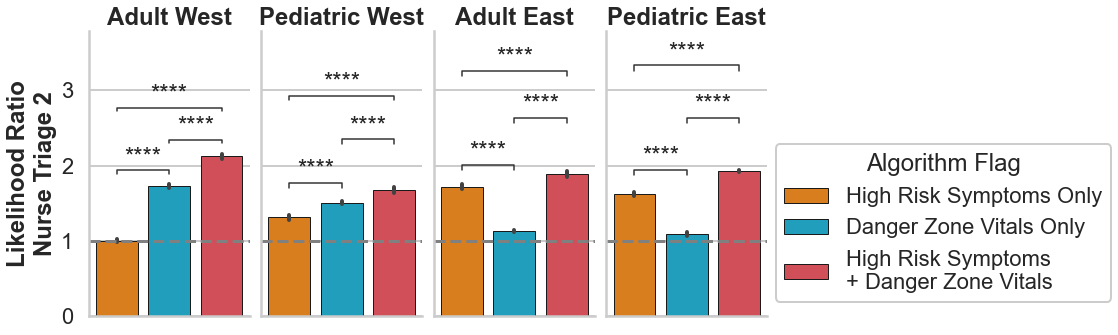

In [12]:
import seaborn as sns
from statannotations.Annotator import Annotator
sns.set_theme('poster',style='whitegrid')#,font_scale=1.2)
flag_colors = {
    'High Risk Symptoms Only': '#F77F00',  # Orange 
    'Danger Zone Vitals Only': '#06AED5',  # Blue 
    'High Risk Symptoms\n+ Danger Zone Vitals': '#E63946',  # Red 
}
plot_df2 = plot_df.copy()
plot_df2['Flag_Type'] = plot_df2['Flag_Type'].apply(lambda x: x.replace(
    'High Risk Symptoms + Danger Zone Vitals',
    'High Risk Symptoms\n+ Danger Zone Vitals'
    ))
plt_args=dict(
    data=plot_df2,
    x='Flag_Type',
    order=flag_colors.keys(),
    y='Positive Likelihood Ratio',
    hue='Flag_Type',
    hue_order=flag_colors.keys(),
    
)
def nice_stat(x): return f'{x.median():.2f} [{x.quantile(.25):.2f} - {x.quantile(.75):.2f}]'
display((
    plot_df2
    .groupby(['Center','Flag_Type'])
    ['Positive Likelihood Ratio']
    .apply(nice_stat)
    .unstack()
    [flag_colors.keys()]
))
    
g = sns.catplot(
    kind='bar',
    dodge=False,
    **plt_args,
    col='Center',
    col_order=['Adult West','Pediatric West','Adult East','Pediatric East'],
    palette=list(flag_colors.values()),
    aspect=0.5,
    height=5.5,
    linewidth=1.0,
    errwidth=4,
    capsize=0.0,
    edgecolor='k',
    legend='full',
    legend_out=True
)
g.refline(y=1.0)
g.set_titles(template='{col_name}', fontweight='bold',fontsize=14)
g.set_xlabels('')
# g.set_xticklabels(rotation=60, ha='right')
g.set_xticklabels([])
g.set_ylabels('Likelihood Ratio\nNurse Triage 2', fontweight='bold')
# sns.move_legend(g, loc=[0.25,0.34], ncols=3, title='Algorithm Flag', frameon=True, framealpha=1, fontsize=17)
plt.legend(
    loc=[1.05,0.05],
    title='Algorithm Flag', 
    frameon=True, 
    framealpha=1, 
    # fontsize=17
    # labels=['High Risk Symptoms','Danger Zone Vitals','High Risk Symptoms\n+ Danger Zone Vitals']
)
plt.subplots_adjust(wspace=0.07)
# plt.tight_layout()
import itertools as it
for k,ax in g.axes_dict.items():
    # ax.set_xlabel(ax.get_xlabel(), fontsize=24)
    # ax.set_ylabel('Admission Likelihood (%)',fontsize=22)
    # ax.spines['top'].set_visible(True)
    # ax.spines['right'].set_visible(True)
    # ax.set_title(ax.get_title(),fontsize=24)
    labels=['High Risk Symptoms Only','Danger Zone Vitals Only','High Risk Symptoms\n+ Danger Zone Vitals']
    pairs = [(element) for element in it.combinations(labels,2)]
    df = plot_df2[plot_df2['Center']==k]
    plt_args['data'] = df
    print(list(pairs))
    # pairs=[((center, 3), (center, 2)) for center in center_map.values()]
    print('center',k)
    # display(plt_args['data'])
    display((
        df
        .groupby(['Center','Flag_Type'])
        ['Positive Likelihood Ratio']
        .apply(nice_stat)
        .unstack()
        [flag_colors.keys()]
    ))
    annotator = Annotator(ax, pairs, **plt_args)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
    annotator.apply_and_annotate()

plt.savefig('paper/figures/likelihood_ratios_flag_type.pdf',dpi=400, bbox_inches='tight')

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


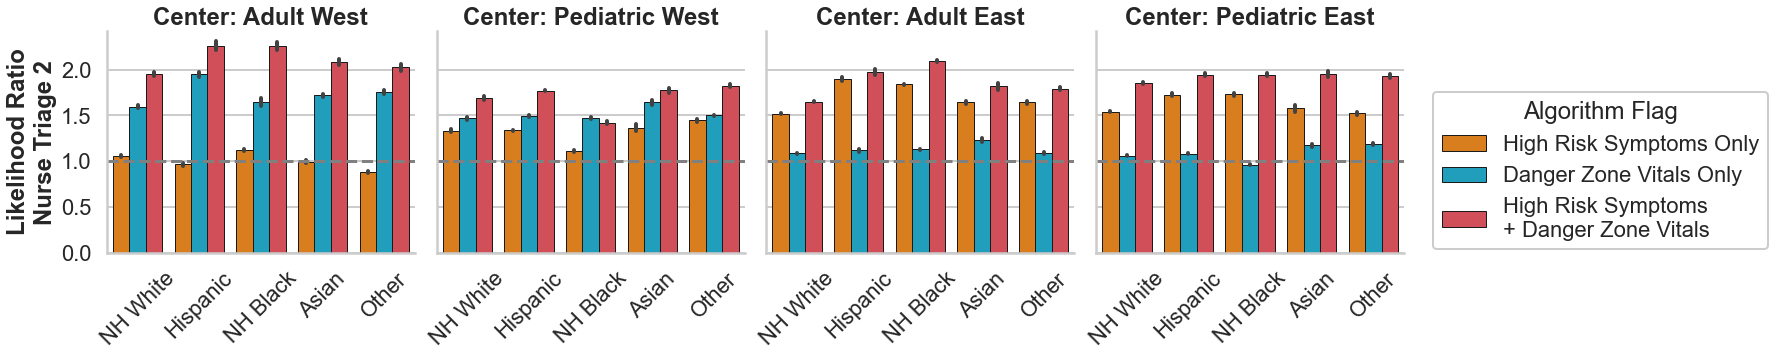

In [6]:
import seaborn as sns
sns.set_theme('poster',style='whitegrid')#,font_scale=1.2)
flag_colors = {
    'High Risk Symptoms Only': '#F77F00',  # Orange 
    'Danger Zone Vitals Only': '#06AED5',  # Blue 
    'High Risk Symptoms\n+ Danger Zone Vitals': '#E63946',  # Red 
}
plot_df2 = plot_df.copy()
plot_df2['Flag_Type'] = plot_df2['Flag_Type'].apply(lambda x: x.replace(
    'High Risk Symptoms + Danger Zone Vitals',
    'High Risk Symptoms\n+ Danger Zone Vitals'
    ))
g = sns.catplot(
    kind='bar',
    data=plot_df2,
    x='Race',
    y='Positive Likelihood Ratio',
    col='Center',
    col_order=['Adult West','Pediatric West','Adult East','Pediatric East'],
    hue='Flag_Type',
    hue_order=flag_colors.keys(),
    palette=list(flag_colors.values()),
    aspect=1.0,
    height=5,
    linewidth=1.0,
    errwidth=4,
    capsize=0.0,
    edgecolor='k',
)
g.refline(y=1.0)
g.set_titles(template='{col_var}: {col_name}', fontweight='bold',fontsize=16)
g.set_xlabels('')
g.set_xticklabels(rotation=45)
g.set_ylabels('Likelihood Ratio\nNurse Triage 2', fontweight='bold')
# sns.move_legend(g, loc=[0.25,0.34], ncols=3, title='Algorithm Flag', frameon=True, framealpha=1, fontsize=17)

sns.move_legend(
    g, 
    loc=[0.805,0.3],
    title='Algorithm Flag', 
    frameon=True, 
    framealpha=1, 
    # fontsize=17
    # labels=['High Risk Symptoms','Danger Zone Vitals','High Risk Symptoms\n+ Danger Zone Vitals']
)
plt.subplots_adjust(wspace=0.07)
# plt.tight_layout()

plt.savefig('paper/figures/likelihood_ratios_flag_type.pdf',dpi=400, bbox_inches='tight')

In [7]:
plot_df['Flag_Type']

0     High Risk Symptoms + Danger Zone Vitals
1                     High Risk Symptoms Only
2                     Danger Zone Vitals Only
3     High Risk Symptoms + Danger Zone Vitals
4                     High Risk Symptoms Only
                       ...                   
16                    High Risk Symptoms Only
17                    Danger Zone Vitals Only
18    High Risk Symptoms + Danger Zone Vitals
19                    High Risk Symptoms Only
20                    Danger Zone Vitals Only
Name: Flag_Type, Length: 840, dtype: object

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


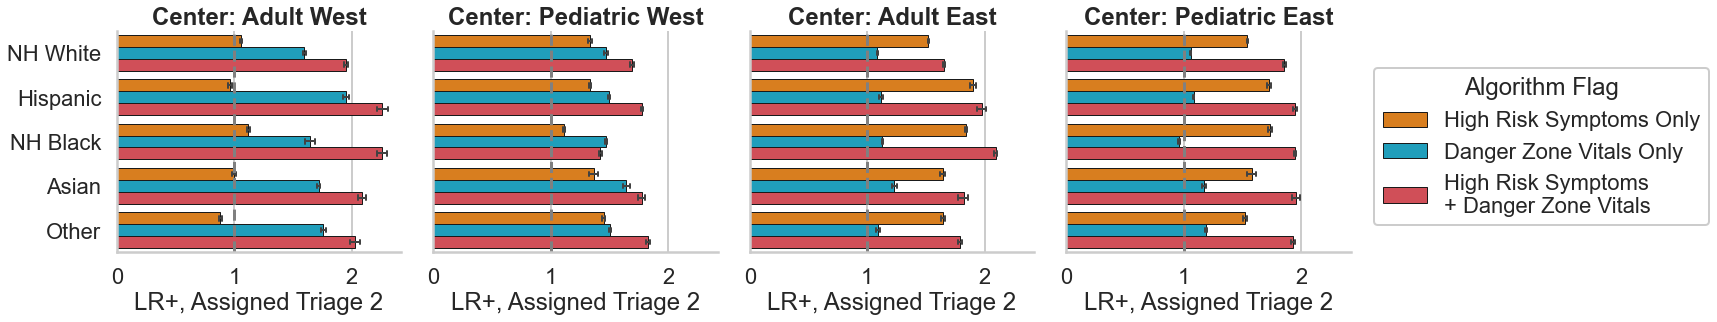

In [8]:
import seaborn as sns
sns.set_theme('poster',style='whitegrid')
plot_df2 = plot_df.copy()
plot_df2['Flag_Type'] = plot_df2['Flag_Type'].apply(lambda x: x.replace(
    'High Risk Symptoms + Danger Zone Vitals',
    'High Risk Symptoms\n+ Danger Zone Vitals'
    ))
flag_colors = {
    'High Risk Symptoms Only': '#F77F00',  # Orange 
    'Danger Zone Vitals Only': '#06AED5',  # Blue 
    'High Risk Symptoms\n+ Danger Zone Vitals': '#E63946',  # Red 
}
g = sns.catplot(
    kind='bar',
    data=plot_df2,
    y='Race',
    x='Positive Likelihood Ratio',
    col='Center',
    col_order=['Adult West','Pediatric West','Adult East','Pediatric East'],
    hue='Flag_Type',
    hue_order=flag_colors.keys(),
    palette=list(flag_colors.values()),
    # aspect=1.4,
    # height=6,
    linewidth=1.0,
    errwidth=2,
    capsize=0.1,
    edgecolor='k',
)
g.refline(x=1.0)
g.set_titles(template='{col_var}: {col_name}', fontweight='bold')
g.set_ylabels('')
g.set_xlabels('LR+, Assigned Triage 2')

sns.move_legend(
    g, 
    loc=[0.8,0.3],
    title='Algorithm Flag', 
    frameon=True, 
    framealpha=1, 
    # labels=['High Risk Symptoms','Danger Zone Vitals','High Risk Symptoms\n+ Danger Zone Vitals']
)
# plt.tight_layout()
plt.savefig('paper/figures/likelihood_ratios_flag_type2.pdf',dpi=400, bbox_inches='tight')

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


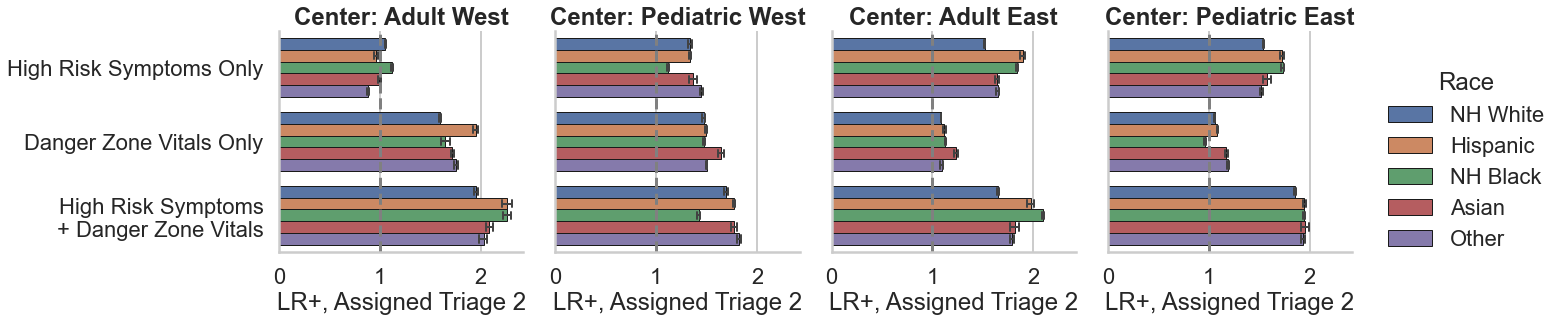

In [9]:
import seaborn as sns
sns.set_theme('poster',style='whitegrid')

flag_colors = {
    'High Risk Symptoms Only': '#F77F00',  # Orange 
    'Danger Zone Vitals Only': '#06AED5',  # Blue 
    'High Risk Symptoms\n+ Danger Zone Vitals': '#E63946',  # Red 
}
g = sns.catplot(
    kind='bar',
    data=plot_df2,
    y='Flag_Type',
    x='Positive Likelihood Ratio',
    col='Center',
    col_order=['Adult West','Pediatric West','Adult East','Pediatric East'],
    # hue='Flag_Type',
    hue='Race',
    order=flag_colors.keys(),
    # palette=
    # palette=list(flag_colors.values()),
    # aspect=1.4,
    # height=6,
    linewidth=1.0,
    errwidth=2,
    capsize=0.1,
    edgecolor='k',
)
g.refline(x=1.0)
g.set_titles(template='{col_var}: {col_name}', fontweight='bold')
g.set_ylabels('')
g.set_xlabels('LR+, Assigned Triage 2')
# sns.move_legend(g, loc=[0.3,0.14], ncols=3, title='Race', frameon=True, framealpha=1)
# plt.tight_layout()
plt.savefig('paper/figures/likelihood_ratios_race.pdf',dpi=400, bbox_inches='tight')